# **Lennard-Jones Potential**

Now we will try the leapfrog scheme using the Lennard-Jones potential instead of gravity. **Lennard-Jones (LJ) potential** models the interaction between a pair of neutral atoms or molecules. It captures two competing physical effects:

- **Short-range repulsion**: due to Pauli exclusion (overlapping electron clouds)
- **Long-range attraction**: due to induced dipole–dipole (van der Waals) interactions

The potential is given by:

$$V(r) = 4\varepsilon \left[ \left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^{6} \right]$$

where:
- $r$ is the distance between the two particles
- $\varepsilon$ is the depth of the potential well (energy scale)
- $\sigma$ is the finite distance at which $V(r) = 0$ (length scale)

The force on a particle is derived from the potential:

$$F(r) = -\frac{dV}{dr} = \frac{24\varepsilon}{r} \left[ 2\left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^{6} \right]$$

Key reference points:
- **Equilibrium distance**: $r_{\min} = 2^{1/6}\,\sigma \approx 1.122\,\sigma$, where $F = 0$ and $V = -\varepsilon$
- **Zero crossing**: $V(r) = 0$ at $r = \sigma$
- For $r < r_{\min}$: force is **repulsive** (pushes apart)
- For $r > r_{\min}$: force is **attractive** (pulls together)

  Equilibrium distance : r_min    = 1.1225
  Circular orbit speed : v_orbit  = 0.0000
  Escape speed         : v_escape = 1.4142


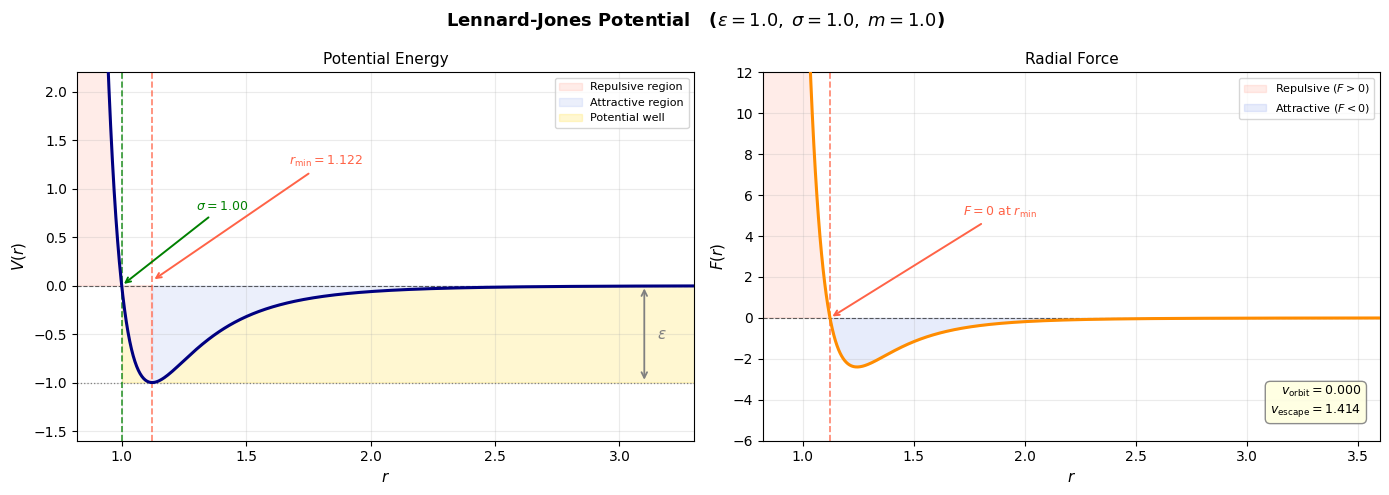

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#  eps   : depth of the potential well — larger values mean stronger attraction
#  sigma : distance at which V = 0 — larger values mean bigger effective size
#  m     : particle mass — does not affect the potential shape, but scales the orbital and escape velocities
                                     
eps   = 1.0
sigma = 1.0
m     = 1.0

# Physics functions
def V_LJ(r, eps=eps, sigma=sigma):
    """Lennard-Jones potential energy."""
    sr6 = (sigma / r) ** 6
    return 4 * eps * (sr6**2 - sr6)

def F_LJ(r, eps=eps, sigma=sigma):
    """Radial LJ force. Positive values indicate repulsion."""
    sr6 = (sigma / r) ** 6
    return (24 * eps / r) * (2 * sr6**2 - sr6)

# Reference values 
r_min    = 2**(1/6) * sigma
v_escape = np.sqrt(2 * eps / m)
v_orbit  = np.sqrt(r_min * abs(F_LJ(r_min)) / m)

print(f"  Equilibrium distance : r_min    = {r_min:.4f}")
print(f"  Circular orbit speed : v_orbit  = {v_orbit:.4f}")
print(f"  Escape speed         : v_escape = {v_escape:.4f}")

# Plot range
r = np.linspace(0.82 * sigma, 3.6 * sigma, 800)
V = V_LJ(r)
F = F_LJ(r)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    fr'Lennard-Jones Potential   ($\varepsilon={eps},\; \sigma={sigma},\; m={m}$)',
    fontsize=13, fontweight='bold'
)

# Graph for Potential
ax = axes[0]

ax.fill_between(r, V, 0,
                where=(r < r_min), alpha=0.12, color='tomato',
                label='Repulsive region')
ax.fill_between(r, V, 0,
                where=(r >= r_min), alpha=0.10, color='royalblue',
                label='Attractive region')
ax.fill_between(r, V, -eps,
                where=((V < 0) & (r >= sigma)), alpha=0.18, color='gold',
                label='Potential well')

ax.plot(r, V, color='navy', lw=2.2, zorder=5)
ax.axhline(0,     color='k',      lw=0.8, ls='--', alpha=0.6)
ax.axhline(-eps,  color='gray',   lw=0.9, ls=':')
ax.axvline(r_min, color='tomato', lw=1.2, ls='--', alpha=0.8)
ax.axvline(sigma, color='green',  lw=1.2, ls='--', alpha=0.8)

ax.annotate(
    fr'$r_{{\min}} = {r_min:.3f}$',
    xy=(r_min, 0.05 * eps),
    xytext=(r_min + 0.55 * sigma, 1.2 * eps),
    arrowprops=dict(arrowstyle='->', color='tomato', lw=1.4),
    fontsize=9, color='tomato', va='bottom'
)

ax.annotate(
    '', xy=(3.1 * sigma, -eps), xytext=(3.1 * sigma, 0),
    arrowprops=dict(arrowstyle='<->', color='gray', lw=1.3)
)
ax.text(3.15 * sigma, -eps / 2, r'$\varepsilon$',
        fontsize=11, color='gray', va='center')

ax.annotate(
    fr'$\sigma = {sigma:.2f}$',
    xy=(sigma, 0),
    xytext=(sigma + 0.3 * sigma, 0.75 * eps),
    arrowprops=dict(arrowstyle='->', color='green', lw=1.4),
    fontsize=9, color='green', va='bottom'
)

ax.set_ylim(-1.6 * eps, 2.2 * eps)
ax.set_xlim(r[0], 3.3 * sigma)
ax.set_xlabel(r'$r$', fontsize=11)
ax.set_ylabel(r'$V(r)$', fontsize=11)
ax.set_title('Potential Energy', fontsize=11)
ax.legend(fontsize=8, loc='upper right')
ax.grid(alpha=0.25)

# Graph for Force
ax = axes[1]

ax.fill_between(r, F, 0,
                where=(F > 0), alpha=0.12, color='tomato',
                label=r'Repulsive ($F > 0$)')
ax.fill_between(r, F, 0,
                where=(F < 0), alpha=0.12, color='royalblue',
                label=r'Attractive ($F < 0$)')

ax.plot(r, F, color='darkorange', lw=2.2, zorder=5)
ax.axhline(0,     color='k',      lw=0.8, ls='--', alpha=0.6)
ax.axvline(r_min, color='tomato', lw=1.2, ls='--', alpha=0.8)

ax.annotate(
    r'$F = 0$ at $r_{\min}$',
    xy=(r_min, 0),
    xytext=(r_min + 0.6 * sigma, 5 * eps),
    arrowprops=dict(arrowstyle='->', color='tomato', lw=1.4),
    fontsize=9, color='tomato'
)

textstr = (
    fr'$v_{{\mathrm{{orbit}}}} = {v_orbit:.3f}$' + '\n'
    fr'$v_{{\mathrm{{escape}}}} = {v_escape:.3f}$'
)
ax.text(0.97, 0.06, textstr, transform=ax.transAxes,
        fontsize=9, va='bottom', ha='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                  edgecolor='gray', alpha=0.9))

ax.set_ylim(-6 * eps, 12 * eps)
ax.set_xlim(r[0], r[-1])
ax.set_xlabel(r'$r$', fontsize=11)
ax.set_ylabel(r'$F(r)$', fontsize=11)
ax.set_title('Radial Force', fontsize=11)
ax.legend(fontsize=8, loc='upper right')
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

#### **Stable Circular Orbits in the LJ Potential**

A stable circular orbit exists when the net radial force provides exactly the centripetal acceleration required for circular motion:

$$\frac{mv^2}{r} = |F(r)|$$

Solving for the orbital speed at radius $r$:

$$v_{\text{orbit}}(r) = \sqrt{\frac{r \, |F(r)|}{m}}$$

#### Stability Condition

For an orbit to be **stable**, small perturbations must not grow unboundedly. This requires:

$$\frac{d^2 V_{\text{eff}}}{dr^2} > 0$$

where $V_{\text{eff}}$ is the effective potential including the centrifugal term. In practice for the LJ potential, stable circular orbits exist only near $r_{\min} = 2^{1/6}\sigma$ where the potential well is deepest.

#### Critical (Escape) Velocity

For a particle at the equilibrium distance $r_{\min}$, the **escape velocity** is the speed needed to escape to $r \to \infty$ (where $V = 0$):

$$v_{\text{escape}} = \sqrt{\frac{2\varepsilon}{m}}$$

since the particle must overcome the potential well of depth $\varepsilon$.

| Velocity regime | Behaviour |
|---|---|
| $v < v_{\text{orbit}}$ | Particle spirals inward → collision |
| $v = v_{\text{orbit}}$ | Stable circular orbit |
| $v_{\text{orbit}} < v < v_{\text{escape}}$ | Elliptical / bounded orbit |
| $v \geq v_{\text{escape}}$ | Unbound trajectory |

  Orbital speed at r_min  : v_orbit  = 0.0000
  Escape speed from r_min : v_escape = 1.4142
  Ratio v_escape/v_orbit  : 27397079.0030


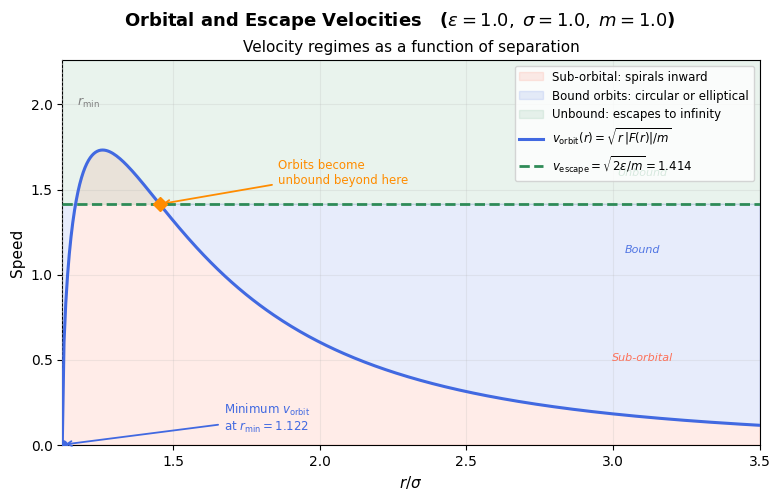

In [2]:
# Orbital speed as a function of r
# Circular orbit condition: centripetal force = LJ force
# => v_orbit(r) = sqrt(r |F(r)| / m)
# Only meaningful for r >= r_min, where the force is attractive

r_orb = np.linspace(r_min, 3.5 * sigma, 400)
v_orb = np.sqrt(r_orb * np.abs(F_LJ(r_orb)) / m)

print(f"  Orbital speed at r_min  : v_orbit  = {v_orbit:.4f}")
print(f"  Escape speed from r_min : v_escape = {v_escape:.4f}")
print(f"  Ratio v_escape/v_orbit  : {v_escape / v_orbit:.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle(
    fr'Orbital and Escape Velocities   ($\varepsilon={eps},\; \sigma={sigma},\; m={m}$)',
    fontsize=13, fontweight='bold'
)

ax.fill_between(r_orb, 0, v_orb,
                alpha=0.12, color='tomato',
                label='Sub-orbital: spirals inward')


ax.fill_between(r_orb, v_orb, v_escape,
                where=(v_orb < v_escape), alpha=0.12, color='royalblue',
                label='Bound orbits: circular or elliptical')


ax.fill_between(r_orb, v_escape, v_escape * 1.6,
                alpha=0.10, color='seagreen',
                label='Unbound: escapes to infinity')

ax.plot(r_orb / sigma, v_orb, color='royalblue', lw=2.2, zorder=5,
        label=r'$v_\mathrm{orbit}(r) = \sqrt{r\,|F(r)|/m}$')
ax.axhline(v_escape, color='seagreen', lw=2.0, ls='--', zorder=5,
           label=fr'$v_\mathrm{{escape}} = \sqrt{{2\varepsilon/m}} = {v_escape:.3f}$')
ax.axvline(r_min / sigma, color='gray', lw=1.2, ls=':', zorder=4)

ax.plot(r_min / sigma, v_orbit, 'o', color='royalblue', ms=7, zorder=6)
ax.annotate(
    fr'Minimum $v_\mathrm{{orbit}}$' + '\n' + fr'at $r_\min = {r_min:.3f}$',
    xy=(r_min / sigma, v_orbit),
    xytext=(r_min / sigma + 0.55, v_orbit + 0.08),
    arrowprops=dict(arrowstyle='->', color='royalblue', lw=1.3),
    fontsize=8.5, color='royalblue', ha='left'
)

cross_idx = int(np.argmin(np.abs(v_orb - v_escape)))
r_cross   = r_orb[cross_idx] / sigma
ax.plot(r_cross, v_escape, 'D', color='darkorange', ms=7, zorder=6)
ax.annotate(
    'Orbits become\nunbound beyond here',
    xy=(r_cross, v_escape),
    xytext=(r_cross + 0.4, v_escape + 0.12),
    arrowprops=dict(arrowstyle='->', color='darkorange', lw=1.3),
    fontsize=8.5, color='darkorange', ha='left'
)

ax.text(r_min / sigma + 0.05, v_escape * 1.45,
        r'$r_{\min}$', fontsize=9, color='gray', va='top')

ax.text(3.1, v_escape * 0.35, 'Sub-orbital',
        fontsize=8, color='tomato', alpha=0.9, ha='center', style='italic')
ax.text(3.1, v_escape * 0.80, 'Bound',
        fontsize=8, color='royalblue', alpha=0.9, ha='center', style='italic')
ax.text(3.1, v_escape * 1.12, 'Unbound',
        fontsize=8, color='seagreen', alpha=0.9, ha='center', style='italic')

ax.set_xlim(r_orb[0] / sigma, r_orb[-1] / sigma)
ax.set_ylim(0, v_escape * 1.6)
ax.set_xlabel(r'$r / \sigma$', fontsize=11)
ax.set_ylabel('Speed', fontsize=11)
ax.set_title('Velocity regimes as a function of separation', fontsize=11)
ax.legend(fontsize=8.5, loc='upper right')
ax.grid(alpha=0.2)

plt.tight_layout
plt.show()

#### **Leapfrog Integration of LJ Dynamics**

We integrate Newton's equations using the **leapfrog (Störmer–Verlet)** scheme:

$$v_{i+1/2} = v_i + \frac{F(r_i)}{m} \cdot \frac{\Delta t}{2}$$

$$r_{i+1} = r_i + v_{i+1/2} \cdot \Delta t$$

$$v_{i+1} = v_{i+1/2} + \frac{F(r_{i+1})}{m} \cdot \frac{\Delta t}{2}$$

The leapfrog integrator is **symplectic** — it conserves a shadow Hamiltonian, making it ideal for long-time orbital simulations where energy drift would otherwise accumulate.

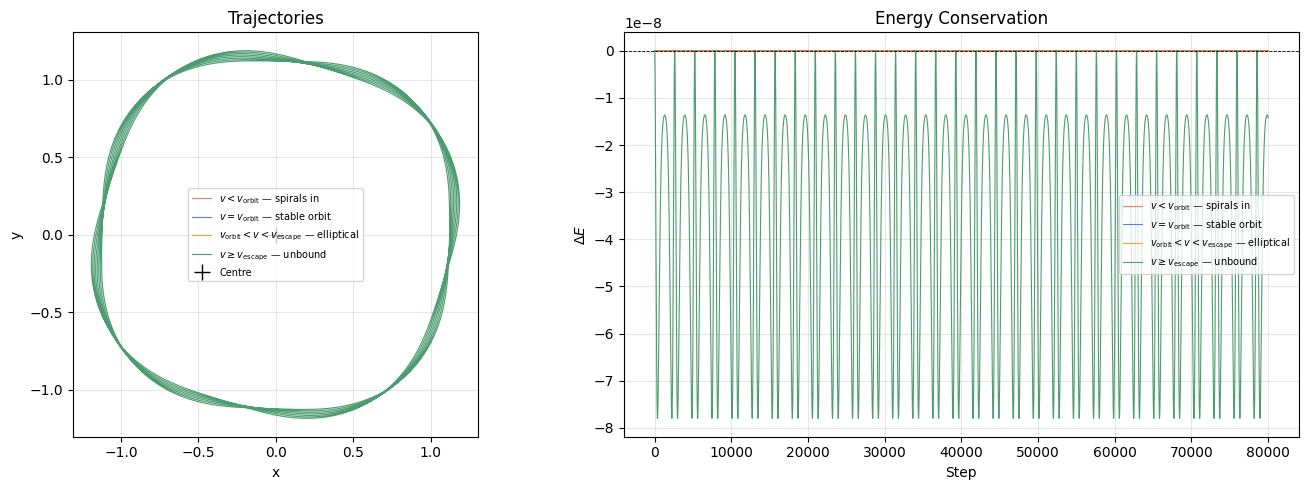

In [3]:
def leapfrog_LJ(r0, v0, dt=5e-4, n_steps=80_000):
    """
    Leapfrog integrator for a test particle moving under the LJ potential.
    The scheme is symplectic, so total energy is conserved over long runs
    without the secular drift you would see from a plain Euler method.
    """
    r_vec, v_vec = np.array(r0, float), np.array(v0, float)
    traj, energies = [r_vec.copy()], []

    def accel(rv):
        d = np.linalg.norm(rv)
        # Hard cutoff at 0.5σ to avoid the singularity at r = 0
        return np.zeros(2) if d < 0.5 * sigma else F_LJ(d) * rv / d / m

    a = accel(r_vec)
    for _ in range(n_steps):
        v_vec += 0.5 * dt * a       # half-step velocity update
        r_vec += dt * v_vec         # full-step position update
        a      = accel(r_vec)
        v_vec += 0.5 * dt * a       # complete the velocity update
        traj.append(r_vec.copy())
        energies.append(0.5 * m * np.dot(v_vec, v_vec) + V_LJ(np.linalg.norm(r_vec)))

    return np.array(traj), np.array(energies)

# Four representative initial conditions
# Every particle starts at r_min on the x-axis with a purely tangential
# velocity, so the orbit begins perpendicular to the radial direction.

cases = {
    r"$v < v_\mathrm{orbit}$ — spirals in":                     ([0.0, 0.6  * v_orbit],  'tomato'),
    r"$v = v_\mathrm{orbit}$ — stable orbit":                    ([0.0, 1.0  * v_orbit],  'royalblue'),
    r"$v_\mathrm{orbit} < v < v_\mathrm{escape}$ — elliptical": ([0.0, 1.3  * v_orbit],  'darkorange'),
    r"$v \geq v_\mathrm{escape}$ — unbound":                     ([0.0, 1.05 * v_escape], 'seagreen'),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, (v0, color) in cases.items():
    traj, energies = leapfrog_LJ([r_min, 0.0], v0)
    axes[0].plot(traj[:, 0], traj[:, 1], lw=0.8, color=color, alpha=0.85, label=label)
    axes[1].plot(energies - energies[0],  lw=0.8, color=color, alpha=0.85, label=label)

axes[0].plot(0, 0, 'k+', ms=12, label='Centre')
axes[0].set_aspect('equal'); axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].set_title('Trajectories'); axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)

axes[1].axhline(0, color='k', lw=0.6, ls='--')
axes[1].set_xlabel('Step'); axes[1].set_ylabel(r'$\Delta E$')
axes[1].set_title('Energy Conservation'); axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()